Step 04 - Burgers' Equation

Here, the goal was to understand the equation that combines both non-linear convection and diffusion. Burgers' equation is one of the most famous equations in CFD because it has many of the same mathematical properties as the Navier–Stokes equations, but it is much simpler.

It allows us to learn: nonlinear transport, diffusion, shock formation, numerical stability, boundary conditions, without the complexity of pressure and multiple velocity components present in the NS equation.

In [52]:
# importing neccesary libraries
import numpy as np
import matplotlib.pyplot as plt
import sympy

# telling sympy to use latex for printing all outputs
from sympy import init_printing   
init_printing(use_latex=True) 

In [53]:
# initializing symbolic variables and phi
x, nu, t = sympy.symbols('x nu t')
phi = (sympy.exp(-(x - 4 * t)**2 / (4 * nu * (t + 1))) + sympy.exp(-(x - 4 * t - 2 * np.pi)**2 / (4 * nu * (t + 1))))

# testing the output of
phi

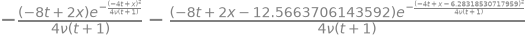

In [54]:
phi_prime = phi.diff(x) #first derivative of phi with respect to x

#testing phi_prime
phi_prime

In [55]:
# initializing the full initial condition u(x,0) = -2*nu*(phi_prime/phi) + 4
u = -2 * nu * (phi_prime / phi) + 4

# using the lambdify function to convert the symbolic expression into a numerical function
u_func = sympy.lambdify((t, x, nu), u)

# testing the output of u_func
u_func(1, 4, 3)

In [56]:
# Finalizing the Burgers' equation solution

#initializing the parameters for the solution
nx = 101
nt = 100
dx = 2 * np.pi / (nx - 1)
nu = 0.07
dt = dx * nu

# creating the spatial grid and initializing the solution array
x = np.linspace(0, 2 * np.pi, nx)
un = np.empty(nx)
t = 0

# converting the output of the u_func into a numpy array for plotting
u = np.asarray([u_func(t, x0, nu) for x0 in x])

#testing the output of u`
u



array([4.        , 4.06283185, 4.12566371, 4.18849556, 4.25132741,
       4.31415927, 4.37699112, 4.43982297, 4.50265482, 4.56548668,
       4.62831853, 4.69115038, 4.75398224, 4.81681409, 4.87964594,
       4.9424778 , 5.00530965, 5.0681415 , 5.13097336, 5.19380521,
       5.25663706, 5.31946891, 5.38230077, 5.44513262, 5.50796447,
       5.57079633, 5.63362818, 5.69646003, 5.75929189, 5.82212374,
       5.88495559, 5.94778745, 6.0106193 , 6.07345115, 6.136283  ,
       6.19911486, 6.26194671, 6.32477856, 6.38761042, 6.45044227,
       6.51327412, 6.57610598, 6.63893783, 6.70176967, 6.76460125,
       6.82742866, 6.89018589, 6.95176632, 6.99367964, 6.72527549,
       4.        , 1.27472451, 1.00632036, 1.04823368, 1.10981411,
       1.17257134, 1.23539875, 1.29823033, 1.36106217, 1.42389402,
       1.48672588, 1.54955773, 1.61238958, 1.67522144, 1.73805329,
       1.80088514, 1.863717  , 1.92654885, 1.9893807 , 2.05221255,
       2.11504441, 2.17787626, 2.24070811, 2.30353997, 2.36637

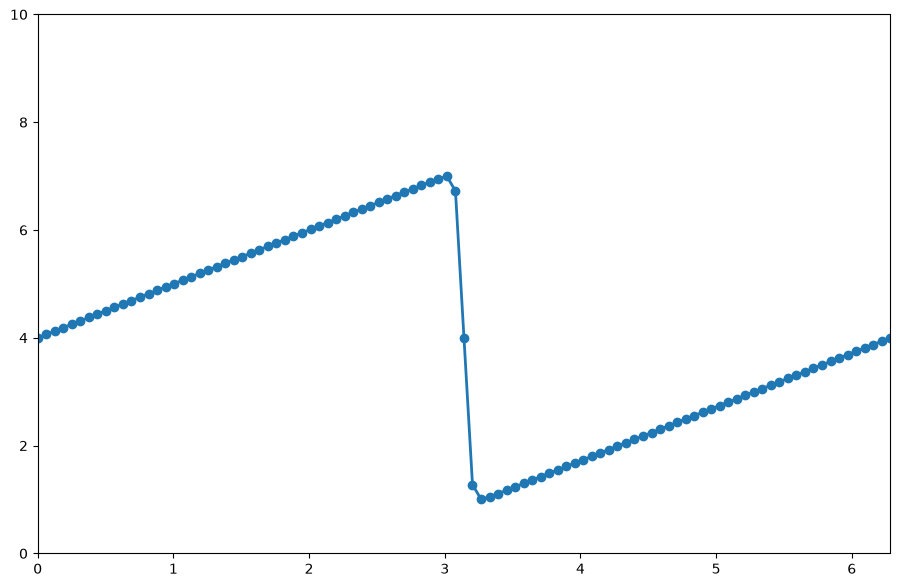

In [57]:
# plotting the results
plt.figure(figsize=(11, 7), dpi=100)
plt.plot(x, u, marker='o', lw=2)
plt.xlim([0, 2 * np.pi])
plt.ylim([0, 10])

In [58]:
# implementing the analytical solution of the Burgers' equation
for n in range(nt):
    un = u.copy()
    for i in range (1, nx-1):
        u[i] = un[i] - un[i] * dt / dx * (un[i] - un[i - 1]) + nu * dt / dx**2 * (un[i + 1] - 2 * un[i] + un[i - 1])

    # initial boundary conditions
    u[0] = un[0] - un[0] * dt / dx * (un[0] - un[-2]) + nu * dt / dx**2 * (un[1] - 2 * un[0] + un[-2])
    u[-1] = u[0]

# analytical u value
u_analytical = np.asarray([u_func(nt * dt, x0, nu) for x0 in x])

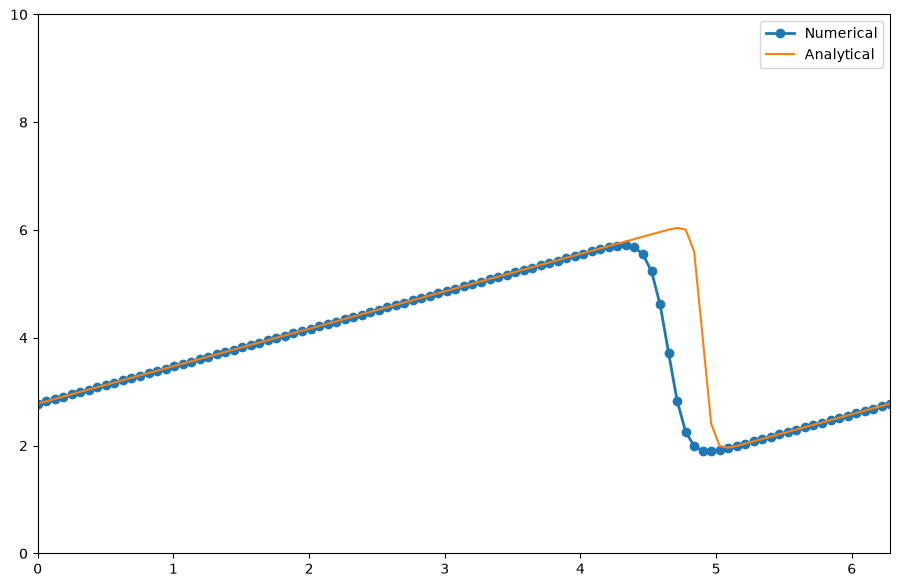

In [59]:
# comparing the analytical solution with the numerical solution
plt.figure(figsize=(11, 7), dpi=100)
plt.plot(x, u, marker='o', lw=2, label='Numerical')
plt.plot(x, u_analytical, label='Analytical')
plt.xlim([0, 2 * np.pi])
plt.ylim([0, 10])
plt.legend();

What i learnt: The parameter (nu) controls how strong the diffusion is